<a href="https://colab.research.google.com/github/Eshachatterjee01/data_science_all/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SVM Support Vector Machine**



**Support Vector Machine (SVM) is a machine learning algorithm used for classification and regression tasks. However, it is mostly used for classification problems.**

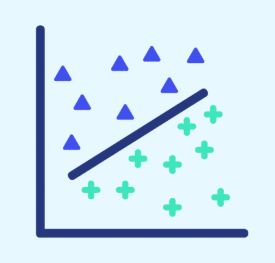

# Goal of SVM:

SVM aims to find the best boundary (decision boundary or hyperplane) that separates different classes of data points in a dataset.
This boundary helps predict the class of new data points.


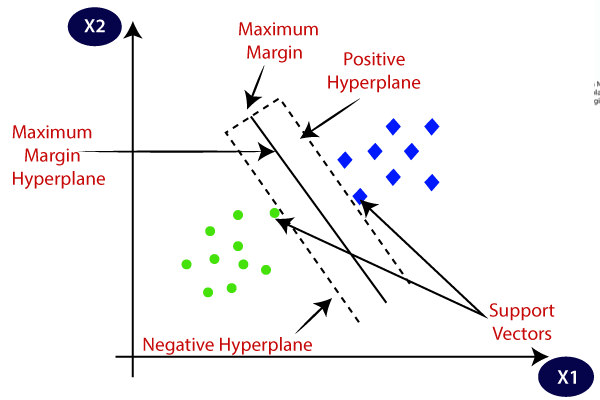

# How SVM Works:

Think of SVM as a way to draw a line (or a surface in higher dimensions) that splits data points into two groups.

It chooses the line that is as far as possible from the nearest data points of each group. These nearest points are called support vectors because they "support" the boundary.

#Key Terms in SVM:

**Hyperplane:** The decision boundary that separates classes.

**Margin:** The distance between the hyperplane and the nearest data points from each class. SVM tries to maximize this margin to make the separation robust.

# Real-Life Example:

**Email Spam Detection:**

SVM can classify emails as "spam" or "not spam" by finding the boundary that separates the two categories based on features like word frequency.

#Advantages and Disadvantages of SVM (Support Vector Machine)

**Advantages:**

Effective in high-dimensional spaces: Works well for datasets with a large number of features.

Robust to overfitting: Particularly effective in scenarios where the number of samples is smaller than the number of features.

Works well with clear margins: Suitable when the classes are clearly separable.

**Disadvantages:**

Computational complexity: Training can be slow for large datasets.

Not suited for large datasets: Performance degrades as the dataset size increases.

Choosing the right kernel: Selecting the correct kernel and hyperparameters requires experimentation.

No direct probabilistic interpretation: Unlike logistic regression, it doesn’t provide probabilities directly.


# Comparison of Classification Models

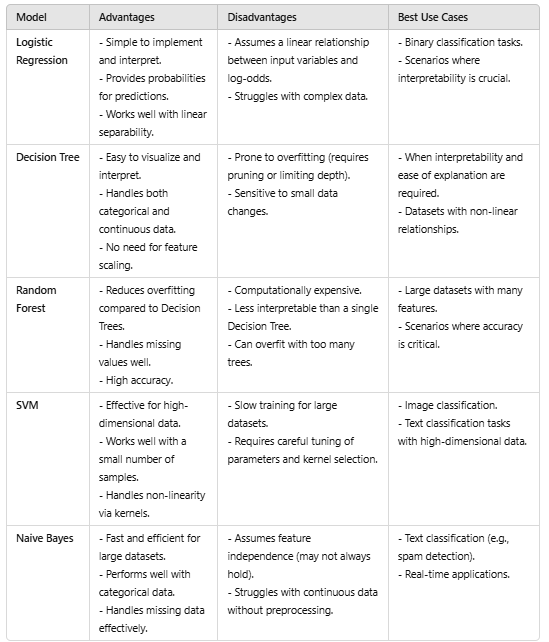

**Key Takeaways:**

**Logistic Regression:** Best for binary classification and scenarios requiring interpretability.

**Decision Tree:** Good for non-linear problems, but needs pruning to avoid overfitting.

**Random Forest:** Balances bias and variance effectively and works well for large datasets.

**SVM:** Ideal for high-dimensional, small datasets but computationally intensive.

**Naive Bayes:** Excellent for text-based tasks with categorical data.

# SVM Implementation

drug.avif

#Objective:

**The objective of this project is to accurately predict the suitable drug outcomes for patients.**

**A kernel function in SVM (Support Vector Machine) is used to transform the input data into a higher-dimensional space. This transformation enables SVM to find a linear boundary in this higher-dimensional space, even when the data is not linearly separable in its original dimension.**


#1)Linear Kernel:

A simple kernel that works by drawing a straight line or hyperplane to separate the data into classes.

Used when the data is linearly separable.

#2)Polynomial Kernel:

A kernel that considers the similarity of points based on polynomial relationships.

Effective for data where relationships between features are more complex but still follow a specific pattern.

#3)Radial Basis Function (RBF) Kernel:

A popular kernel that measures the similarity between points based on their distance.

It is widely used for non-linear data and can handle complex patterns.

#4)Sigmoid Kernel:

A kernel similar to the activation function used in neural networks.

It can model non-linear relationships but is less commonly used compared to other kernels.

# How to Choose a Kernel?

**Linear Kernel:** Use when the data is linearly separable or when the number of features is very high compared to the number of samples.

**RBF Kernel:** Default choice for most non-linear problems; effective for capturing non-linear relationships.

**Polynomial Kernel:** Use for problems where specific polynomial relationships are suspected.

**Sigmoid Kernel:** Rarely used, but can be tried when experimenting with neural network-like behavior.


# Real-Life Example:

**Linear Kernel:** Predicting pass/fail for students based on hours studied and attendance.

**RBF Kernel:** Image classification, where boundaries between classes are complex and non-linear.

**Polynomial Kernel:** Modeling data with polynomial patterns, e.g., predicting stock prices based on past trends.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/drug.csv")

In [ ]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


there are no null,dupliacted values


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Drug'].unique()

array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [ ]:
df['Drug'].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [ ]:
#label encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
for i in df.columns:
  if df[i].dtype == 'object':
    df[i] = le.fit_transform(df[i])

In [ ]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0
...,...,...,...,...,...,...
195,56,0,1,0,11.567,3
196,16,1,1,0,12.006,3
197,52,1,2,0,9.894,4
198,23,1,2,1,14.020,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [ ]:
#model building part

# splitvthe data

x = df.drop('Drug',axis =1)
y =df['Drug']

In [ ]:
x

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043
...,...,...,...,...,...
195,56,0,1,0,11.567
196,16,1,1,0,12.006
197,52,1,2,0,9.894
198,23,1,2,1,14.020


In [ ]:
y

,Drug
0,0
1,3
2,3
3,4
4,0
...,...
195,3
196,3
197,4
198,4


In [ ]:
#train_test_split
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.8,random_state =0)

In [ ]:
#svc classifier---by default it will take rbf

from sklearn.svm import SVC

model = SVC()
#train--using fit
model.fit(x_train,y_train)

#testing --using predict
y_pred = model.predict(x_test)

#importing all the eval metrics
from sklearn.metrics import *
print(accuracy_score(y_test,y_pred) *100)

82.5


In [ ]:
#svc classifier  --- with linear kernal

from sklearn.svm import SVC

model = SVC(kernel = 'linear')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import *
print(accuracy_score(y_test,y_pred) *100)

100.0


In [ ]:
#rbf
#svc classifier---rbf

from sklearn.svm import SVC

model = SVC(kernel ='rbf')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import *
print(accuracy_score(y_test,y_pred) *100)

82.5


In [ ]:

#svc classifier---poly

from sklearn.svm import SVC

model = SVC(kernel ='poly')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import *
print(accuracy_score(y_test,y_pred) *100)

80.0


ValueError: x and y must be the same size

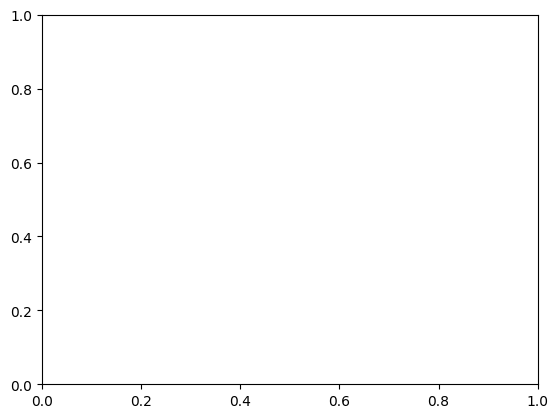

In [ ]:
import plotly.express as px
fig = px.scatter_3d()